<a href="https://colab.research.google.com/github/FaraahJ/Data-Science-Internship-Assignments/blob/main/Week_3_Label_Encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('/content/Diabetes-Classification.csv')
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,Male,25.0,Normal,100,5.7,No,No,Healthy,Regular,No
1,55,Female,30.0,High,120,6.4,Yes,Yes,Poor,No,Yes
2,65,Male,35.0,High,140,7.1,Yes,Yes,Poor,No,Yes
3,75,Female,40.0,High,160,7.8,Yes,Yes,Poor,No,Yes
4,40,Male,20.0,Normal,80,5.0,No,No,Healthy,NaN,No


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         128 non-null    int64  
 1   Gender                      128 non-null    object 
 2   BMI                         125 non-null    float64
 3   Blood Pressure              128 non-null    object 
 4   FBS                         128 non-null    int64  
 5   HbA1c                       128 non-null    float64
 6   Family History of Diabetes  126 non-null    object 
 7   Smoking                     126 non-null    object 
 8   Diet                        126 non-null    object 
 9   Exercise                    127 non-null    object 
 10  Diagnosis                   128 non-null    object 
dtypes: float64(2), int64(2), object(7)
memory usage: 11.1+ KB


In [12]:
df.isnull().sum()

,0
Age,0
Gender,0
BMI,3
Blood Pressure,0
FBS,0
HbA1c,0
Family History of Diabetes,2
Smoking,2
Diet,2
Exercise,1


In [13]:
df = df.dropna()
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,Male,25.0,Normal,100,5.7,No,No,Healthy,Regular,No
1,55,Female,30.0,High,120,6.4,Yes,Yes,Poor,No,Yes
2,65,Male,35.0,High,140,7.1,Yes,Yes,Poor,No,Yes
3,75,Female,40.0,High,160,7.8,Yes,Yes,Poor,No,Yes
5,50,Female,25.0,Normal,100,5.7,No,No,Healthy,Regular,No


In [15]:
from sklearn.preprocessing import LabelEncoder
cat_col=['Diagnosis', 'Gender', 'Blood Pressure', 'Family History of Diabetes', 'Smoking', 'Diet', 'Exercise']

le=LabelEncoder()

for col in cat_col:
  df[col]=le.fit_transform(df[col])

df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,1,25.0,2,100,5.7,0,0,0,1,0
1,55,0,30.0,0,120,6.4,1,1,1,0,1
2,65,1,35.0,0,140,7.1,1,1,1,0,1
3,75,0,40.0,0,160,7.8,1,1,1,0,1
5,50,0,25.0,2,100,5.7,0,0,0,1,0


In [32]:
label_encoded=pd.get_dummies(df, columns=['Gender'])
label_encoded.head()

,Age,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis,Gender_index,Blood Pressure_index,Family History of Diabetes_index,Smoking_index,Diet_index,Exercise_index,Gender_0,Gender_1
0,45,25.0,2,100,5.7,0,0,0,1,0,1,2,0,0,0,1,False,True
1,55,30.0,0,120,6.4,1,1,1,0,1,0,0,1,1,1,0,True,False
2,65,35.0,0,140,7.1,1,1,1,0,1,1,0,1,1,1,0,False,True
3,75,40.0,0,160,7.8,1,1,1,0,1,0,0,1,1,1,0,True,False
5,50,25.0,2,100,5.7,0,0,0,1,0,0,2,0,0,0,1,True,False


In [33]:
cat_col=['Gender', 'Exercise', 'Blood Pressure', 'Family History of Diabetes', 'Smoking', 'Diet']
label_encoded= pd.get_dummies(df, columns=cat_col)

label_encoded.head()

,Age,BMI,FBS,HbA1c,Diagnosis,Gender_index,Blood Pressure_index,Family History of Diabetes_index,Smoking_index,Diet_index,...,Exercise_1,Blood Pressure_0,Blood Pressure_1,Blood Pressure_2,Family History of Diabetes_0,Family History of Diabetes_1,Smoking_0,Smoking_1,Diet_0,Diet_1
0,45,25.0,100,5.7,0,1,2,0,0,0,...,True,False,False,True,True,False,True,False,True,False
1,55,30.0,120,6.4,1,0,0,1,1,1,...,False,True,False,False,False,True,False,True,False,True
2,65,35.0,140,7.1,1,1,0,1,1,1,...,False,True,False,False,False,True,False,True,False,True
3,75,40.0,160,7.8,1,0,0,1,1,1,...,False,True,False,False,False,True,False,True,False,True
5,50,25.0,100,5.7,0,0,2,0,0,0,...,True,False,False,True,True,False,True,False,True,False


In [39]:
cat_col=['Gender_index', 'Blood Pressure_index',	'Family History of Diabetes_index', 'Smoking_index',
         'Diet_index', 'Exercise_1',	'Blood Pressure_0',	'Blood Pressure_1',	'Blood Pressure_2',
         'Family History of Diabetes_0',	'Family History of Diabetes_1',	'Smoking_0',	'Smoking_1',	'Diet_0',	'Diet_1']
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in cat_col:
  label_encoded[col]=le.fit_transform(label_encoded[col])

label_encoded.head()

,Age,BMI,FBS,HbA1c,Diagnosis,Gender_index,Blood Pressure_index,Family History of Diabetes_index,Smoking_index,Diet_index,...,Exercise_1,Blood Pressure_0,Blood Pressure_1,Blood Pressure_2,Family History of Diabetes_0,Family History of Diabetes_1,Smoking_0,Smoking_1,Diet_0,Diet_1
0,45,25.0,100,5.7,0,1,2,0,0,0,...,1,0,0,1,1,0,1,0,1,0
1,55,30.0,120,6.4,1,0,0,1,1,1,...,0,1,0,0,0,1,0,1,0,1
2,65,35.0,140,7.1,1,1,0,1,1,1,...,0,1,0,0,0,1,0,1,0,1
3,75,40.0,160,7.8,1,0,0,1,1,1,...,0,1,0,0,0,1,0,1,0,1
5,50,25.0,100,5.7,0,0,2,0,0,0,...,1,0,0,1,1,0,1,0,1,0


In [40]:
df.describe()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis,Gender_index,Blood Pressure_index,Family History of Diabetes_index,Smoking_index,Diet_index,Exercise_index
count,118.00000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000
mean,43.09322,0.516949,36.220339,0.677966,163.559322,7.924576,0.398305,0.627119,0.627119,0.372881,0.254237,0.516949,0.677966,0.398305,0.627119,0.627119,0.372881
std,21.46792,0.501844,16.542685,0.904701,62.244698,2.178564,0.491637,0.485633,0.485633,0.485633,0.437288,0.501844,0.904701,0.491637,0.485633,0.485633,0.485633
min,12.00000,0.000000,10.000000,0.000000,80.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.00000,0.000000,24.000000,0.000000,120.000000,6.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,40.00000,1.000000,34.000000,0.000000,160.000000,7.800000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,56.50000,1.000000,48.500000,2.000000,220.000000,9.900000,1.000000,1.000000,1.000000,1.000000,0.750000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000
max,185.00000,1.000000,105.000000,2.000000,280.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118 entries, 0 to 127
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               118 non-null    int64  
 1   Gender                            118 non-null    int64  
 2   BMI                               118 non-null    float64
 3   Blood Pressure                    118 non-null    int64  
 4   FBS                               118 non-null    int64  
 5   HbA1c                             118 non-null    float64
 6   Family History of Diabetes        118 non-null    int64  
 7   Smoking                           118 non-null    int64  
 8   Diet                              118 non-null    int64  
 9   Exercise                          118 non-null    int64  
 10  Diagnosis                         118 non-null    int64  
 11  Gender_index                      118 non-null    int8   
 12  Blood Pressur

In [ ]:
#dtypes are all integers for label encoded data

In [42]:
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis,Gender_index,Blood Pressure_index,Family History of Diabetes_index,Smoking_index,Diet_index,Exercise_index
0,45,1,25.0,2,100,5.7,0,0,0,1,0,1,2,0,0,0,1
1,55,0,30.0,0,120,6.4,1,1,1,0,1,0,0,1,1,1,0
2,65,1,35.0,0,140,7.1,1,1,1,0,1,1,0,1,1,1,0
3,75,0,40.0,0,160,7.8,1,1,1,0,1,0,0,1,1,1,0
5,50,0,25.0,2,100,5.7,0,0,0,1,0,0,2,0,0,0,1


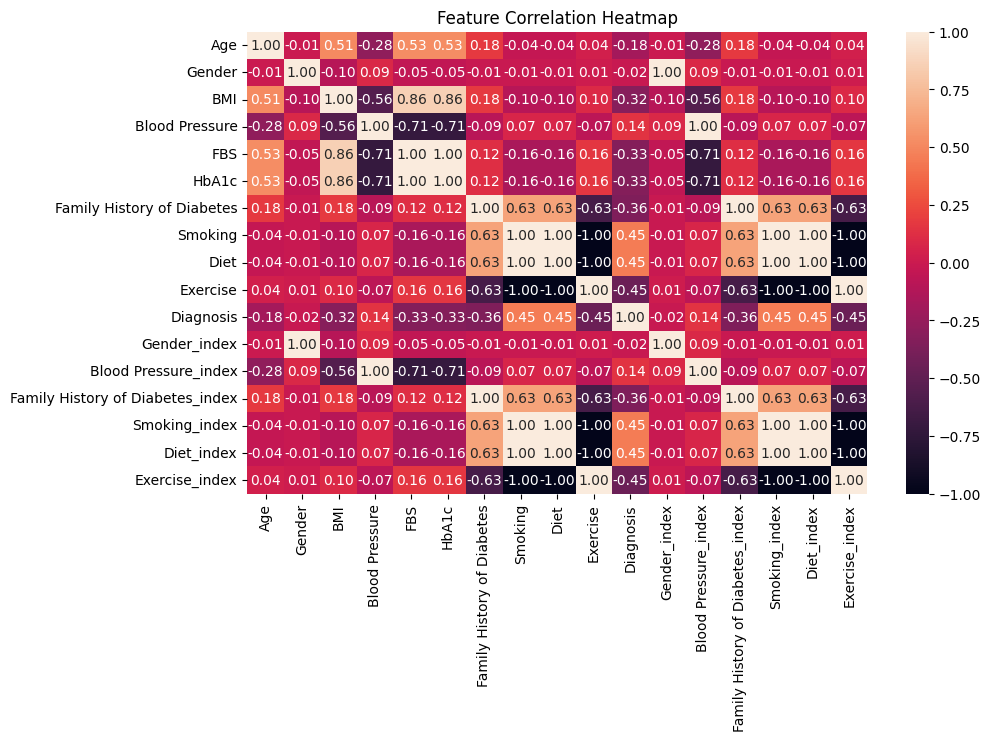

In [43]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

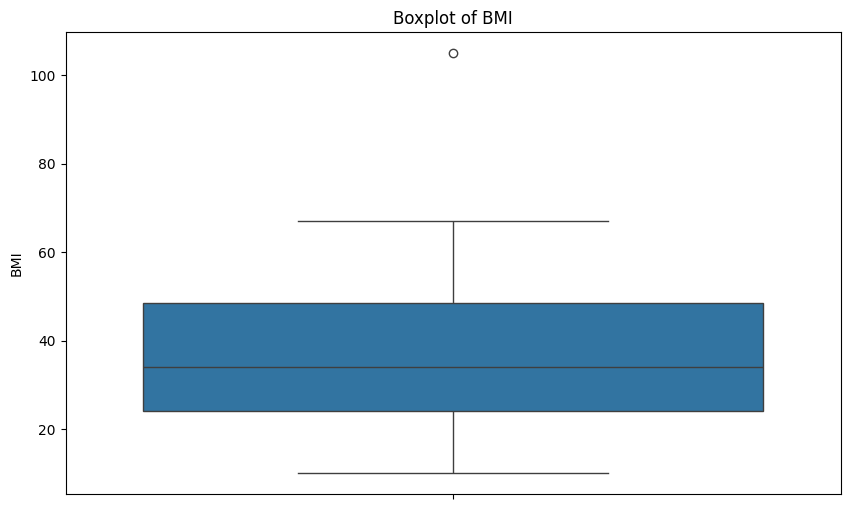

In [44]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df['BMI'])
plt.title('Boxplot of BMI')
plt.show()

In [45]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func= f_classif, k=5)

In [52]:
x=label_encoded.drop('Diagnosis', axis=1)
y=label_encoded['Diagnosis']

In [53]:
x_selected=selector.fit_transform(x,y)
selected_features=x.columns[selector.get_support()]
print(selected_features)

Index(['Exercise_1', 'Smoking_0', 'Smoking_1', 'Diet_0', 'Diet_1'], dtype='object')


In [54]:
x1=label_encoded[selected_features]
x1

,Exercise_1,Smoking_0,Smoking_1,Diet_0,Diet_1
0,1,1,0,1,0
1,0,0,1,0,1
2,0,0,1,0,1
3,0,0,1,0,1
5,1,1,0,1,0
...,...,...,...,...,...
123,0,0,1,0,1
124,0,0,1,0,1
125,0,0,1,0,1
126,0,0,1,0,1


In [55]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.3, random_state=10)
x1_train, x1_test, y_train, y_test=train_test_split(x,y,test_size=0.3, random_state=10)

In [56]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier(n_neighbors=5)
knn_selected=KNeighborsClassifier(n_neighbors=5)

In [57]:
knn.fit(x_train, y_train)
y_pred_knn=knn.predict(x_test)

knn_selected.fit(x1_train, y_train)
y_pred_knn1=knn_selected.predict(x1_test)

In [58]:
from sklearn.metrics import classification_report

print("nKNN Performance:")
print(classification_report(y_test, y_pred_knn))

print("nKNN_Selected Performance:")
print(classification_report(y_test, y_pred_knn1))

nKNN Performance:
              precision    recall  f1-score   support

           0       0.85      0.73      0.79        30
           1       0.20      0.33      0.25         6

    accuracy                           0.67        36
   macro avg       0.52      0.53      0.52        36
weighted avg       0.74      0.67      0.70        36

nKNN_Selected Performance:
              precision    recall  f1-score   support

           0       0.85      0.73      0.79        30
           1       0.20      0.33      0.25         6

    accuracy                           0.67        36
   macro avg       0.52      0.53      0.52        36
weighted avg       0.74      0.67      0.70        36



In [ ]:
#accuracy higher value than one encoded data
#f1 score is larger

In [59]:
from sklearn import svm
from sklearn.svm import SVC

svm=SVC(kernel='rbf', probability=True, random_state=10 )
svm_selected=SVC(kernel='rbf', probability=True, random_state=10)

In [60]:
svm.fit(x_train, y_train)
y_pred_svm=svm.predict(x_test)

svm_selected.fit(x1_train, y_train)
y_pred_svm1=svm_selected.predict(x1_test)

In [61]:
from sklearn.metrics import classification_report

print("SVM Performance:")
print(classification_report(y_test, y_pred_svm))

print("SVM_Selected Performance:")
print(classification_report(y_test, y_pred_svm1))

SVM Performance:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        30
           1       0.00      0.00      0.00         6

    accuracy                           0.83        36
   macro avg       0.42      0.50      0.45        36
weighted avg       0.69      0.83      0.76        36

SVM_Selected Performance:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        30
           1       0.00      0.00      0.00         6

    accuracy                           0.83        36
   macro avg       0.42      0.50      0.45        36
weighted avg       0.69      0.83      0.76        36



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

<Axes: >

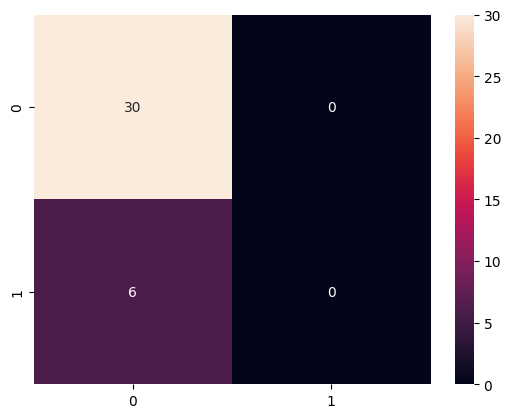

In [62]:
# confusion metrics and ROC curve for all features
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred_svm)
sns.heatmap(cm,annot=True)

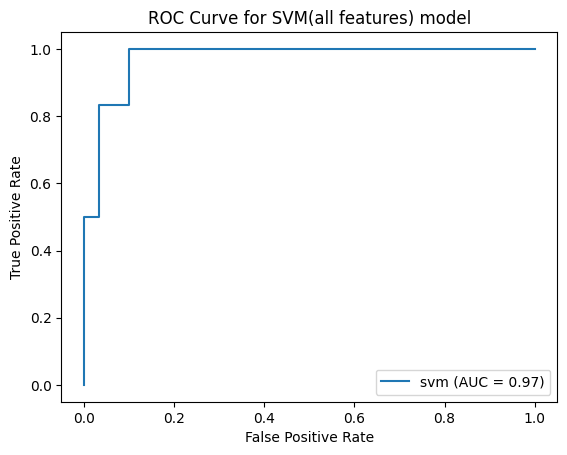

In [63]:
from sklearn.metrics import roc_auc_score, roc_curve

y_proba = svm.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'{'svm'} (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM(all features) model')
plt.legend()
plt.show()

<Axes: >

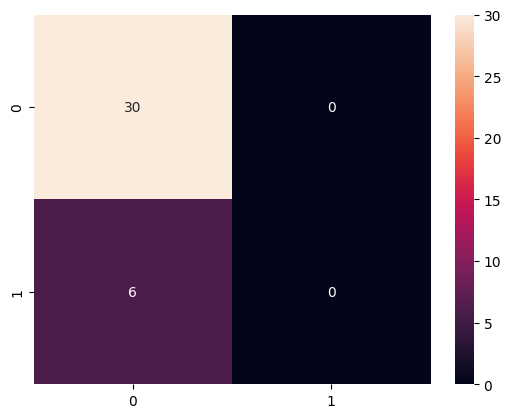

In [64]:
#cm and ROC of selected features
cm_selected=confusion_matrix(y_test,y_pred_svm1)
sns.heatmap(cm_selected,annot=True)

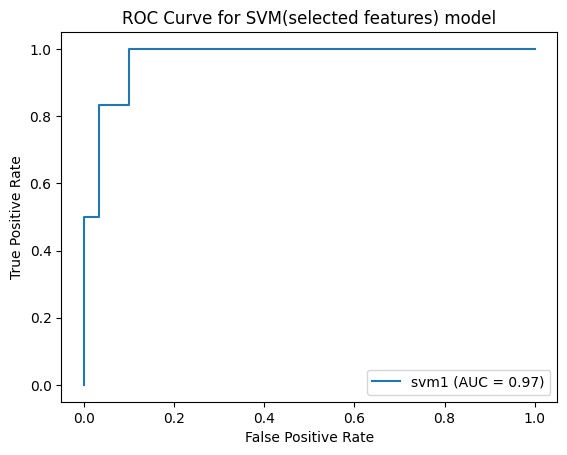

In [65]:
y_proba = svm_selected.predict_proba(x1_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'{'svm1'} (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM(selected features) model')
plt.legend()
plt.show()